In [1]:
#sys.path.append('../braidpool/tests/') # Run `jupyter notebook` in the braidpool/tests directory, or add the path here
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = [12,4]
from math import sqrt
import braid
from simulator import *
bead_color          = ( 27/255, 158/255, 119/255, 1)    # Greenish
genesis_color       = (217/255,  95/255,   2/255, 1)    # Orangeish
cohort_color        = (117/255, 112/255, 179/255, 1)    # Purplisha
tip_color           = (231/255,  41/255, 138/255, 1)    # Pinkish
sibling_color       = (102/255, 166/255,  30/255, 1)    # Light Greenish
# A rotating color palette to color cohorts
color_palette = [genesis_color, cohort_color, sibling_color, tip_color]

In [2]:
# A larger network or lower difficulty makes thicker braids
n = Network(50, target=2**240-1, hashrate=800000)
n.simulate(nbeads=30, mine=False) #  use `mine=False` if ${\rm target} < 2^{249}-1$ or so, for the same number of beads.

b = n.nodes[0].braid
parents = dict(b)
children = braid.reverse(parents)
work = braid.descendant_work(parents)
hwpath = braid.highest_work_path(parents, children, work=work)
cohorts = [set(map(int, c)) for c in b.cohorts]
print(f"Generated braid: {len(b.beads)} beads with {len(cohorts)} cohorts, {len(b.tips)} tips, and {len(hwpath)} beads in the highest work path.")

Generated braid: 30 beads with 19 cohorts, 1 tips, and 22 beads in the highest work path.


In [3]:
def extract(braid):
    """ Extract beads in a simpler format for plotting using sequential integers instead of hashes. """
    parents = {} # A parents map suitable for the algorithms in braids.py
    beadmap = {} # Maps hashes to sequential integers
    for bead, beadcounter in zip(braid.beads, range(len(braid.beads))):
        beadmap[bead.hash] = beadcounter
    for bead, beadcounter in zip(braid.beads, range(len(braid.beads))):
        parents[beadcounter] = {beadmap[p.hash] for p in bead.parents}
    return parents

In [6]:
def plot(b: Braid):    
    def add_arrow(ax, source, target, markersize, arrow_head_width=0.4, arrow_head_length=0.5, linewidth=0.3):
        distance = sqrt((target[0] - source[0])**2 + (target[1] - source[1])**2)
        offset = 1.5*markersize/ax.figure.dpi # Adjust this value as needed to keep arrows from overlapping beads, esp if you change DPI
        dx = (target[0] - source[0]) / distance
        dy = (target[1] - source[1]) / distance
        ax.annotate("", xytext=(source[0]+dx*offset, source[1]+dy*offset), xy=(target[0]-dx*offset, target[1]-dy*offset),
                    arrowprops = {'arrowstyle': '->', 'linewidth': linewidth})

    bead_color          = ( 27/255, 158/255, 119/255, 1)    # Greenish
    genesis_color       = (217/255,  95/255,   2/255, 1)    # Orangeish
    cohort_color        = (117/255, 112/255, 179/255, 1)    # Purplisha
    tip_color           = (231/255,  41/255, 138/255, 1)    # Pinkish
    sibling_color       = (102/255, 166/255,  30/255, 1)    # Light Greenish
    # A rotating color palette to color cohorts
    color_palette = [genesis_color, cohort_color, sibling_color, tip_color]
    markersize          = 16

    # Create a graph
    fig, ax  = plt.subplots()
    
    # Construct basic braid objects
    parents  = extract(b)
    children = braid.reverse(parents)
    cohorts  = list(braid.cohorts(parents, children))
    hwpath   = braid.highest_work_path(parents, children)
    layouts  = [braid.layout(c, parents) for c in cohorts]
    layout   = {}
    startx   = 0
    # Put all cohorts together in one layout map
    for cohort_layout, cohort_num in zip(layouts, range(len(cohorts))):
        for b, (x,y) in cohort_layout.items():
            layout[b] = (x+startx, y)
        startx += max([x for x,y in cohort_layout.values()]) + 1
        
    # Plot nodes
    for cohort, i in zip(cohorts, range(len(cohorts))):
        for bead in cohort:
            x,y = layout[bead]
            ax.plot(x, y, 'o', markersize=markersize, markerfacecolor=color_palette[i % len(color_palette)], 
                    markeredgecolor='black', markeredgewidth=0.5)
            ax.text(x, y, str(bead), ha='center', va='center_baseline', color='white', fontsize=10, fontweight='bold')

    # Plot edges (arrows)
    for node, parent_set in parents.items():
        for parent in parent_set:
            if parent in layout and node in layout:
                x1, y1 = layout[parent]
                x2, y2 = layout[node]
                if node in hwpath and parent in hwpath:
                    add_arrow(ax, layout[node], layout[parent], markersize, linewidth=1.5)
                else:
                    add_arrow(ax, layout[node], layout[parent], markersize, linewidth=0.5)
    ax.set_aspect('equal')
    ax.set_ylim(-0.5, max(y for x,y in layout.values())+0.5)
    plt.axis('off')
    plt.tight_layout()
    plt.show()


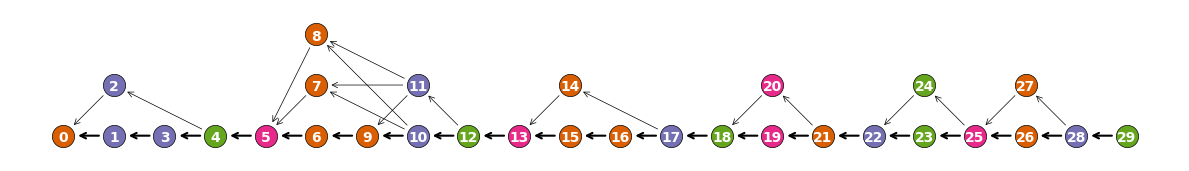

In [7]:
plot(b)